<a href="https://colab.research.google.com/github/nayverp/Ciencia-de-datos-/blob/main/Trabajando_con_medidas_centrales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Agenda
1. Trabajar detaframes
2. Overview de los datos
3. Ejercicios con medidas centrales
4. Analizar graficas


#1. Trabajando con dataframes

In [6]:
#Para instalar librerias
! pip  install statsmodels

In [7]:
!pip install wquantiles

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean #Media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns #Para hacer graficas bonitas
import matplotlib.pyplot as plt

In [9]:
estado=pd.read_csv("/content/state.csv")

In [10]:
#Ver caracteristicas del dataset
estado.head()#Chismosear los 5 primeros registros

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [11]:
estado.head(10)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


In [12]:
#Chismosear los ultimos registros
estado.tail(3)

,State,Population,Murder.Rate,Abbreviation
47,West Virginia,1852994,4.0,WV
48,Wisconsin,5686986,2.9,WI
49,Wyoming,563626,2.7,WY


In [13]:
#Chismosear registros aleatorios
estado.sample(7)

,State,Population,Murder.Rate,Abbreviation
23,Mississippi,2967297,8.6,MS
7,Delaware,897934,5.8,DE
18,Maine,1328361,1.6,ME
30,New Mexico,2059179,4.8,NM
1,Alaska,710231,5.6,AK
39,South Carolina,4625364,6.4,SC
12,Illinois,12830632,5.3,IL


In [14]:
type(estado)

pandas.core.frame.DataFrame

##Overview de los datos
analizando los diferentes datos

In [15]:
#Saber como se llaman las diferentes columnas
estado.columns

Index(['State', 'Population', 'Murder.Rate', 'Abbreviation'], dtype='object')

In [16]:
 #informacion  general del datafreme
 estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


In [17]:
#Medidas de tendencia central de esatistica
estado.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


 estimar la tasa de poblacion y asesinato

In [18]:
estado["Population"].mean()

np.float64(6162876.3)

In [19]:
trim_mean(estado.Population,0.1)#Quiero cortar el 10% de los datos

np.float64(4783697.125)

In [20]:
estado.Population.median()

4436369.5

estimando tasa de asesinato

In [21]:
trim_mean(estado["Murder.Rate"],0.1)

np.float64(3.9450000000000003)

In [22]:
#Media ponderada de la tasa de asesinatos
np.average(estado["Murder.Rate"],weights=estado["Population"])

np.float64(4.445833981123393)

In [23]:
#Mediana ponderada de tasa de asesinatos
wquantiles.median(estado.Population,weights=estado.Population)

np.float64(9660802.03629772)

##Analizar graficas


<Axes: >

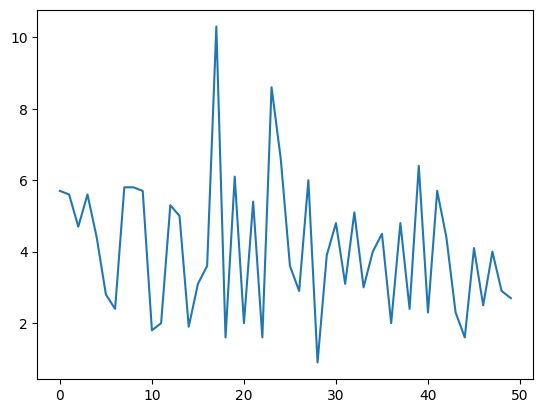

In [24]:
#
estado["Murder.Rate"].plot.line()

<Axes: >

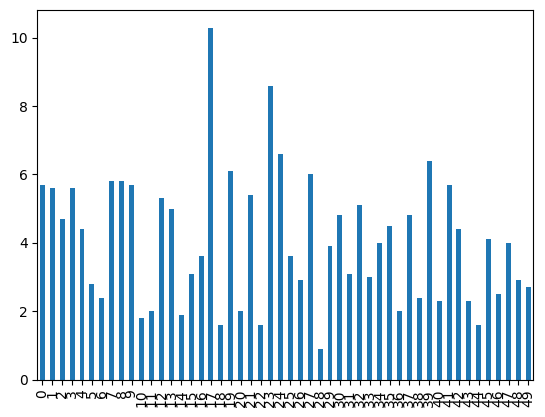

In [25]:
estado["Murder.Rate"].plot.bar()

<Axes: >

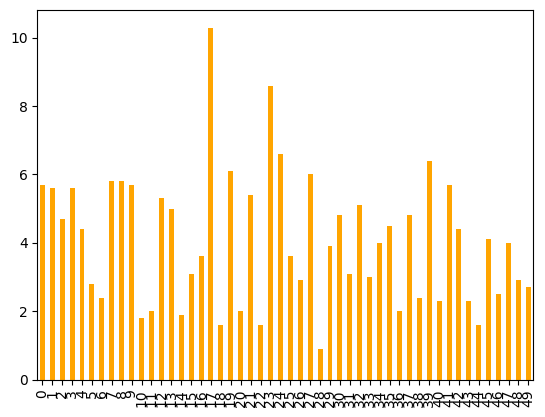

In [26]:
estado["Murder.Rate"].plot.bar(color="orange")

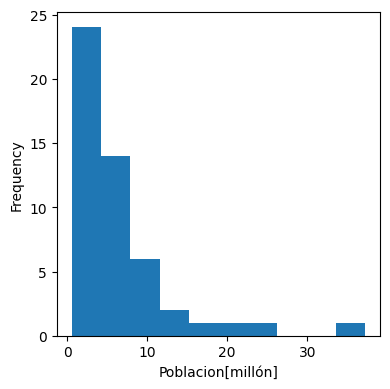

In [27]:
ax=(estado.Population/1_000_000).plot.hist(figsize=(4,4))
ax.set_xlabel("Poblacion[millón]")

plt.tight_layout()
plt.show()

la apoblacion en cada estado administrado tiene una asimatria positiva porque los oflayer tiene la simetria a la derecha

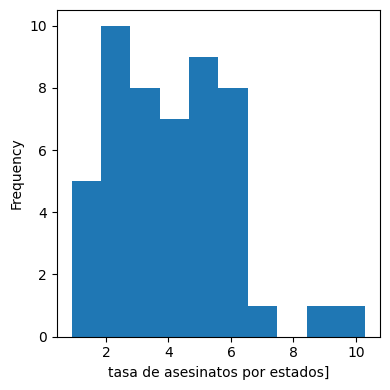

In [56]:
#analizando la nube de tasa de asesinatos
ax=(estado["Murder.Rate"]).plot.hist(figsize=(4,4))
ax.set_xlabel("tasa de asesinatos por estados]")

plt.tight_layout()
plt.show()

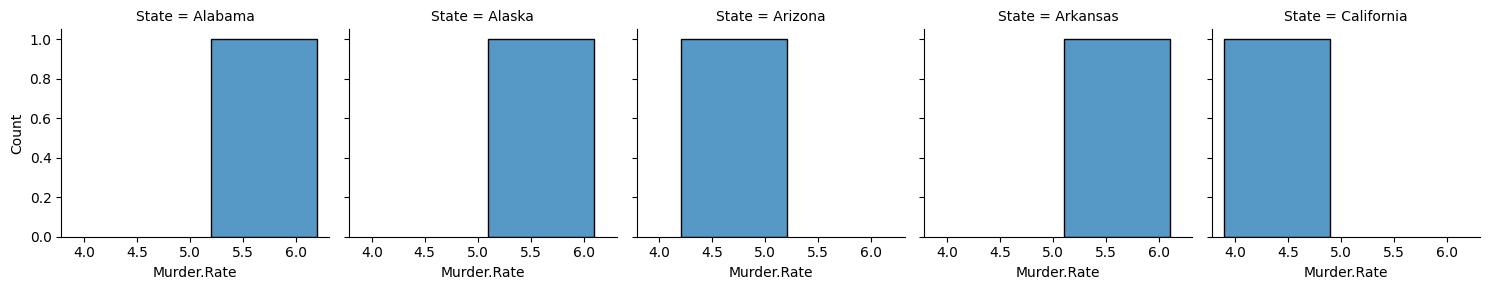

In [37]:
analisis=estado.head()
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

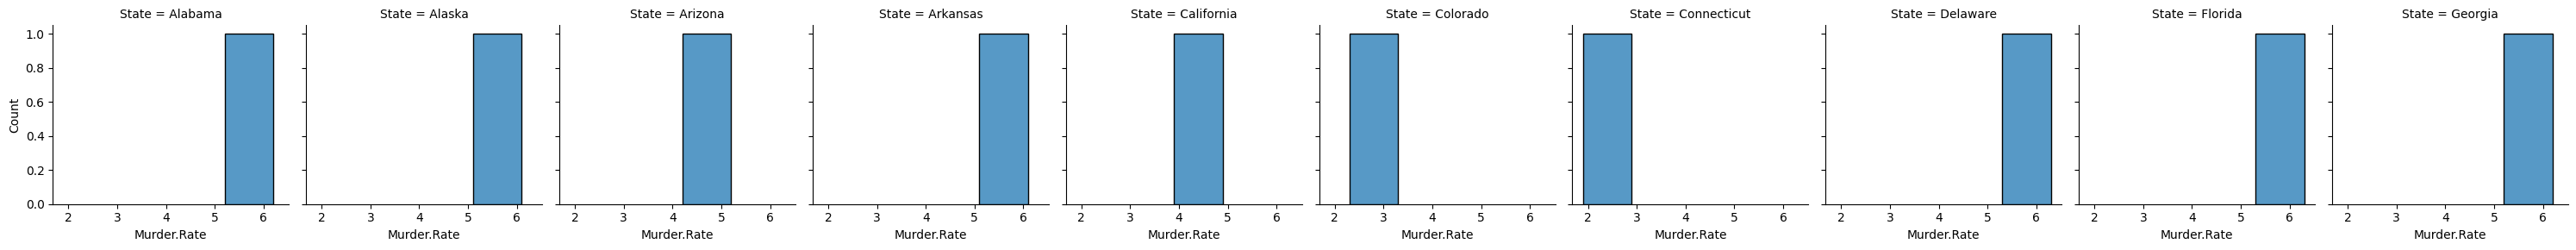

In [45]:
analisis=estado.head(10)
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

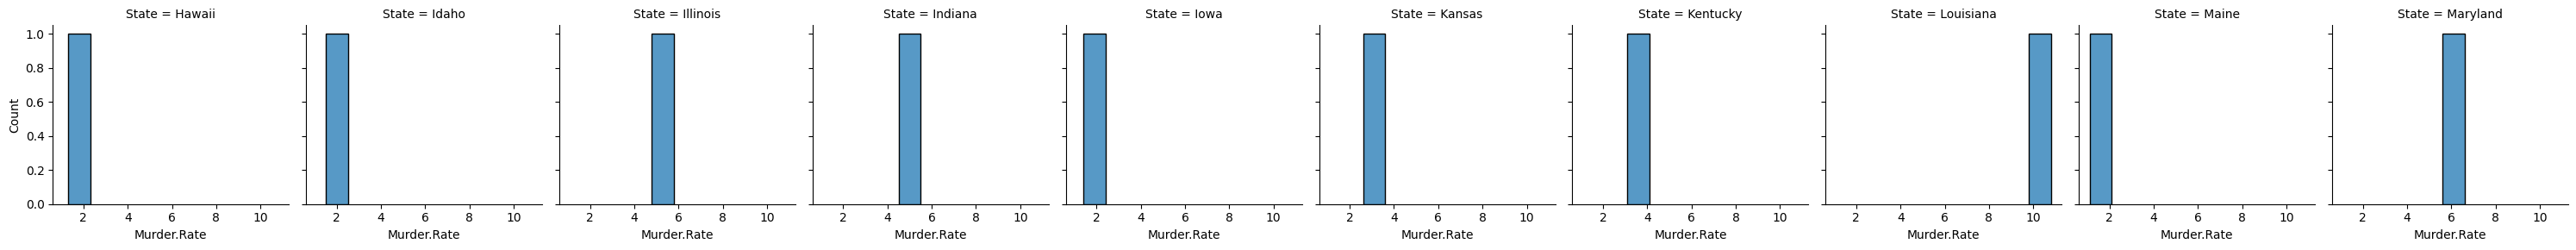

In [51]:
analisis=estado.iloc[10:20]
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

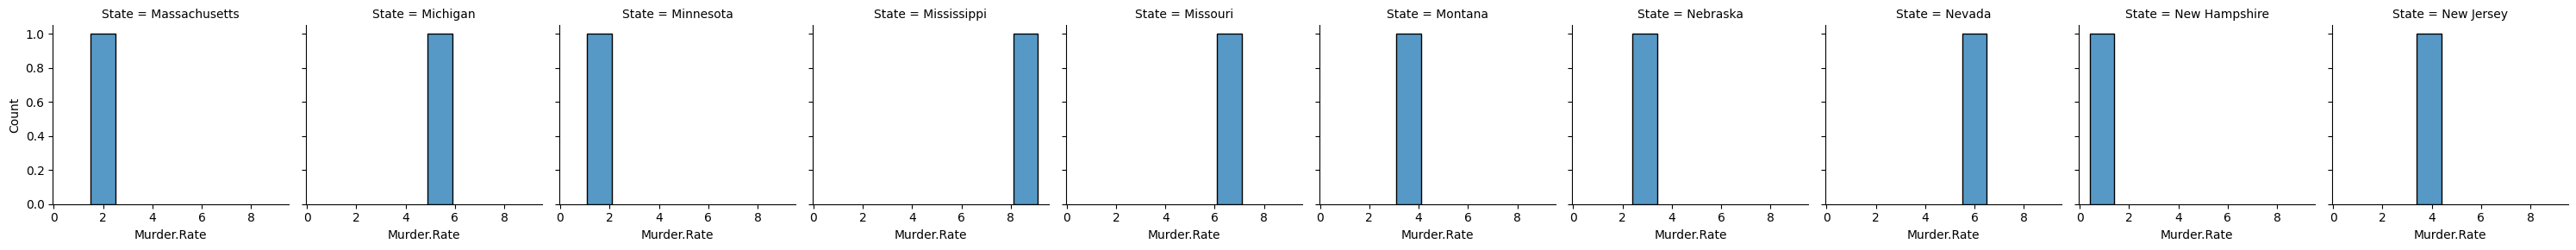

In [52]:
analisis=estado.iloc[20:30]
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

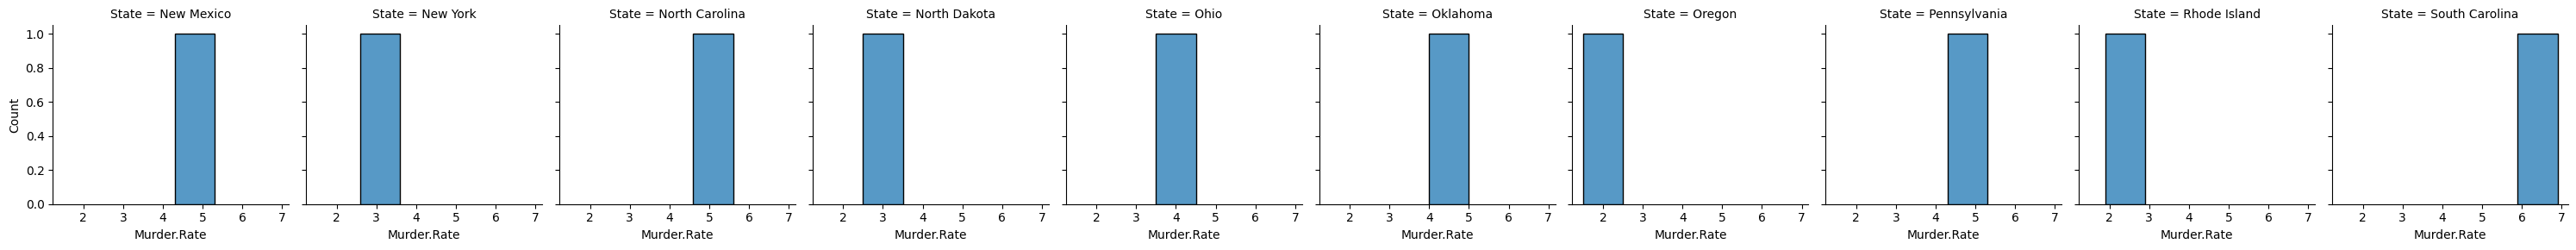

In [53]:
analisis=estado.iloc[30:40]
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

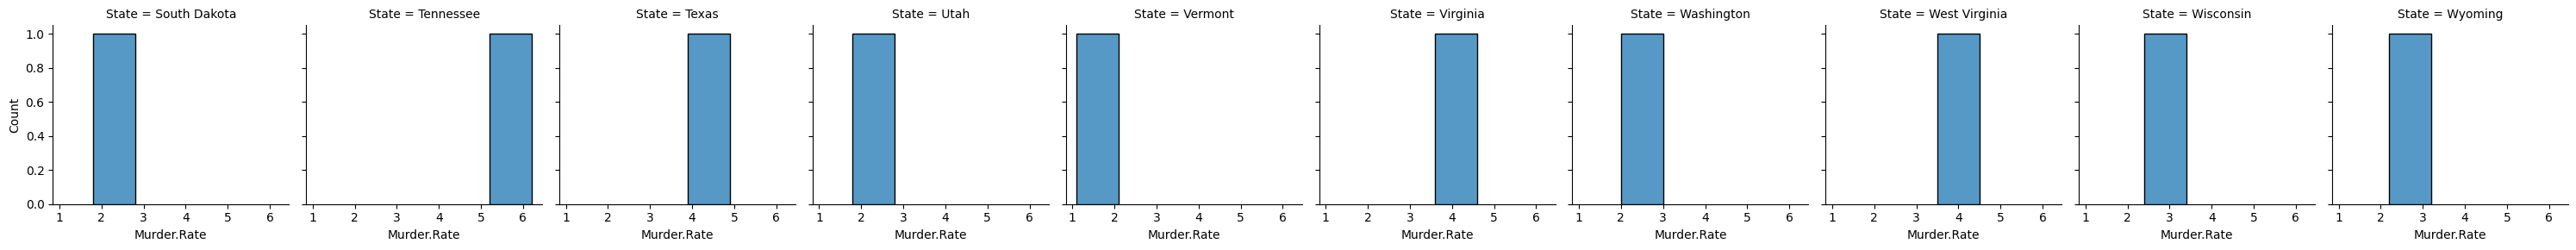

In [54]:
analisis=estado.iloc[40:50]
g=sns.FacetGrid(analisis,col="State")
g.map(sns.histplot,"Murder.Rate")

## graficar todo los valores del estado(10 en 10 o de 5 en 5)

#Estimacion de variavilidad
Mide el grado de agrupacion o dispersion de los datos
1. Desviacion; Distancia entre los valores de observados t la estimacion de la localización
2. Varianza: Suma de los cuadrados de las deviaciones de la media al cuadro devidida por n-1, donde n es el numero de los datos
3.
4. Desviacion media absoluta: Media de los valores absolutos de la desvacion media.
4.

In [49]:
#Desviacion estandar
estado["Population"].std()

6848235.347401142

In [50]:
#calcular el IQR
estado["Population"].quantile(0.75)-estado["Population"].quantile(0.25)

np.float64(4847308.0)

#Exploraion en la distribucion de los datos
1. Diagrama de caja: Visibilizacion rapida de la distribucion de los datos
2. Diagrama de frecuencias: Registro de reciento de valores de datos numericos que caen

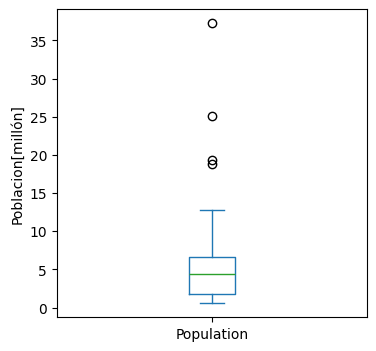

In [55]:
ax=(estado.Population/1_000_000).plot.box(figsize=(4,4))
ax.set_ylabel("Poblacion[millón]")

#Tarea 2: Describir los datos obtenidos del diagrama de caja
plt.show()

## Describir los datos del diagrama  
El diagrama de caja muestra la población en millones. La mediana está aproximadamente en 4 millones el primer cuartil está cerca de 2 millones y el tercer cuartil alrededor de 6 millones el valor mínimo es cercano a 1 millón y el máximo sin contar atípicos es aproximadamente 13 millones logramos observar varios valores atípicos por encima de los 18 millones lo cual indica que hay algunas poblaciones mucho más grandes que el resto la distribución se presenta hacia la derecha.

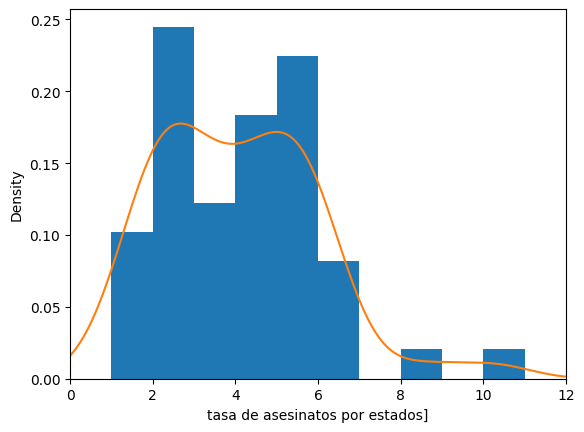

In [62]:
#analizando la nube de tasa de asesinatos
ax=estado["Murder.Rate"].plot.hist(density=True,xlim=[0,12],bins=range(1,12))
estado["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("tasa de asesinatos por estados]")

plt.show()

ACTIVIDAD
1. Cálculo de métricas

En el dataset se calcularon medidas de tendencia central y dispersión. Para la variable Population se obtuvo una media de 6,162,876, una mediana de 4,436,369 y una media recortada de 4,783,697, lo que evidencia asimetría positiva. La desviación estándar fue 6,848,235 y el IQR 4,847,308, indicando alta variabilidad entre estados. Para Murder Rate, la media recortada fue 3.945 y la media ponderada 4.4458, mostrando mayor impacto en estados más poblados.

2. Respuestas de las preguntas
** Sobre estimaciones de variabilidad

* ¿Qué significa que la desviación estándar es casi dos veces mayor que la MAD?
Indica presencia de valores atípicos y asimetría en la distribución, ya que la desviación estándar es sensible a extremos mientras la MAD es robusta.

* ¿Cómo puedo mejorar esta situación?
Aplicando transformaciones (log), usando estadísticas robustas (mediana, MAD) o analizando los outliers por separado.

* Explique el resultado obtenido al calcular IQR
El IQR representa el 50% central de los datos. Un valor alto indica heterogeneidad entre estados y confirma dispersión significativa en la población.

 ** Sobre exploración en distribución de datos:

* ¿Qué información suministran los percentiles?
Permiten clasificar los estados según niveles bajos, medios y altos de tasa de homicidios, mostrando su posición relativa en la distribución.

* ¿Qué información suministra el diagrama de caja?
Muestra mediana, dispersión, asimetría y valores atípicos, permitiendo identificar desigualdades entre estados.

* ¿Cómo agregar los estados en cada intervalo? Interprete.
Se pueden clasificar según cuartiles: menores a Q1 (baja tasa), entre Q1 y Q3 (media) y mayores a Q3 (alta). Esto permite identificar estados con mayor problemática de violencia.

* Explique el resultado del diagrama de dispersión.
Permite observar la relación entre población y tasa de homicidios. La diferencia entre media simple y ponderada sugiere que los estados más poblados tienen mayor influencia en la tasa agregada.